# Test: ParticleSpringForceDiffusionFieldInternal generator

Same diffusion-decay PDE as `test_diffusion_field_generator.ipynb`, but each cell
carries an observable internal state `s_i` (fluorescent reporter):

  ds_i/dt = coeff_s * (c_i - s_i)                                     # linear relaxation toward c
  alpha_i = coeff_emit * (1 - s_i) * sigmoid(beta * (c_i - c_thr))    # smoothly gated emission

Saved per-cell observables (`state.field`):  `[c_i, s_i, ds/dt_target]`.

Layout:
1. **Quick test sim** (low-res grid, ~500 frames) — finishes in < 1 min and verifies the dynamics look right.
2. Full-res sim, diagnostic plots, time-resolved s histogram, 4-panel video.


In [1]:
import sys
import os
sys.path.insert(0, os.path.abspath('../src'))

import torch
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from copy import deepcopy
from tqdm import trange
import matplotlib.animation as animation

from cell_gnn.cell_state import CellState
from cell_gnn.utils import edges_radius_blockwise, choose_boundary_values
from cell_gnn.generators.particle_spring_force_diffusion_field_internal import (
    ParticleSpringForceDiffusionFieldInternal,
)
from cell_gnn.integrators import rk4_step

## Parameters (mirror `dicty_spring_force_rk4_diffusion_field_internal_v1.yaml`)

In [2]:
device = 'cpu'

n_cells = 1000
dimension = 3
n_frames = 8000
delta_t = 0.002
max_radius = 0.075
min_radius = 0.0
noise_level = 0.0

# spring force params: [k_rep, r0, kadh, r_on, delta, mu_f]
cell_params = torch.tensor([50.0, 0.05, 50.0, 0.07, 0.001, 0.033], device=device)

grid_resolution = 100

field_params = {
    'diffusion_coeff': 0.01,
    'lambda_decay':    0.5,
    'grid_resolution': grid_resolution,
    # legacy keys (unused by the new dynamics, kept for back-compat)
    'source_strength': 0.0,
    'source_fraction': 1.0,
    'pulse_period':    0,
    'pulse_duty':      1.0,
    # Initial Gaussian seed so c starts above c_threshold near the centre,
    # otherwise H(c - c_threshold) would never fire and emission would lock at 0.
    'center_0':  torch.tensor([[0.50, 0.50, 0.50]], device=device),
    'amplitude': 0.05,
    'sigma':     0.1,
    'mu_chem': 0.1,
    'chem_saturation_scale': None,
    # New internal-state knobs
    'internal_coeff_s':     2.0,    # ds/dt = coeff_s * (c - s)
    'internal_coeff_emit':  20.0,   # alpha = coeff_emit * (1 - s) * sigmoid(beta*(c - c_thr))
    'internal_c_threshold': 0.01,
    'internal_c_sharpness': 200.0,  # sigmoid β; large → near-Heaviside, small → gentle ramp
    'internal_init_range':  (0.0, 1.0),
    'delta_t':  delta_t,
    'periodic': True,
}

bc_pos, bc_dpos = choose_boundary_values('periodic')

print(f"D={field_params['diffusion_coeff']}, lambda={field_params['lambda_decay']}")
print(f"coeff_s={field_params['internal_coeff_s']} -> tau={1/field_params['internal_coeff_s']:.3f}")
print(f"coeff_emit={field_params['internal_coeff_emit']}, c_threshold={field_params['internal_c_threshold']}")
print(f"seed amplitude={field_params['amplitude']} (peak c at centre)")


D=0.01, lambda=0.5
coeff_s=2.0 -> tau=0.500
coeff_emit=20.0, c_threshold=0.01
seed amplitude=0.05 (peak c at centre)


## Initialize cells & simulator

In [3]:
torch.manual_seed(42)

pos = torch.rand(n_cells, dimension, device=device)
x = CellState(
    index=torch.arange(n_cells, device=device),
    pos=pos,
    vel=torch.zeros(n_cells, dimension, device=device),
    cell_type=torch.zeros(n_cells, dtype=torch.long, device=device),
    field=torch.zeros(n_cells, 3, device=device),  # [c, s, ds/dt] — populated by simulator
)

model = ParticleSpringForceDiffusionFieldInternal(
    aggr_type='add',
    p=cell_params,
    bc_dpos=bc_dpos,
    dimension=dimension,
    noise_model_level=noise_level,
    field_params=field_params,
)

print(f'Cells: {n_cells}, Frames: {n_frames}, dt: {delta_t}')

Cells: 1000, Frames: 8000, dt: 0.002


## Quick test simulation (low-res grid, short run)

Sanity check that the new sigmoid-gated emission and `ds/dt = coeff_s * (c - s)`
dynamics behave as expected. Uses a coarser FFT grid and far fewer frames so the
whole cell runs in under a minute. Plots:
1. probe `c_i(t)` and `s_i(t)` traces (s should chase c with delay 1/coeff_s),
2. `ds/dt_target` vs analytic `coeff_s * (c - s)` scatter — should be perfect diagonal,
3. emission gate `sigmoid(beta*(c - c_thr))` over the c-range actually visited.


quick test sim: 100%|█████████████████████████████████████████████| 500/500 [00:39<00:00, 12.62it/s]


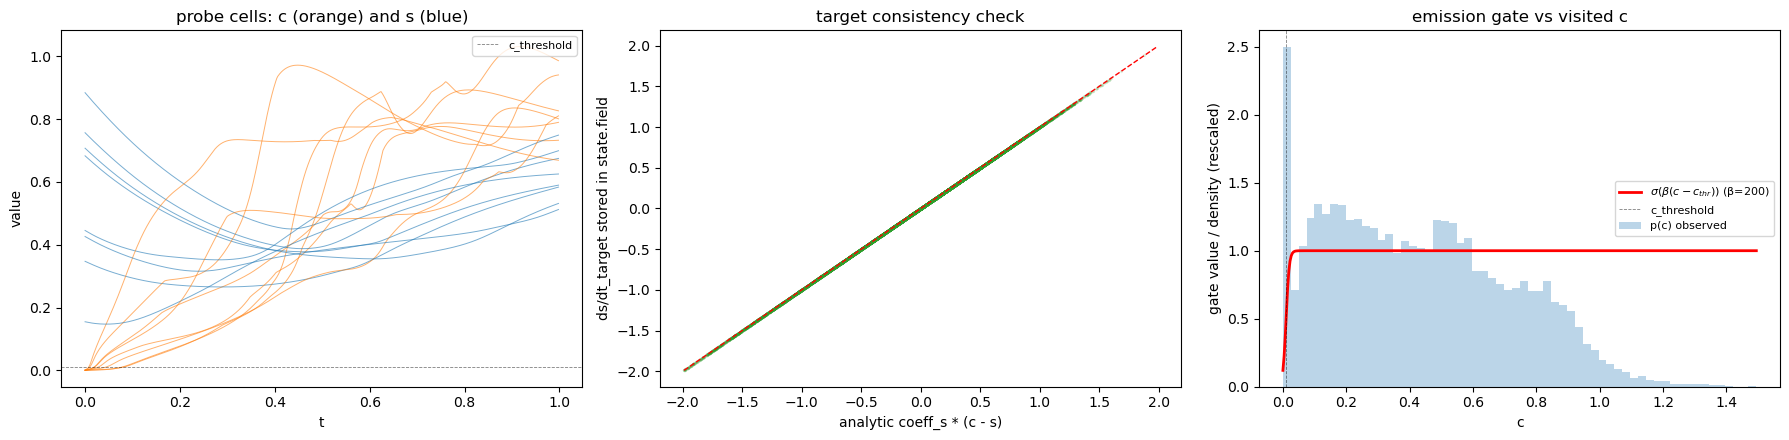

In [4]:
from cell_gnn.generators.particle_spring_force_diffusion_field_internal import (
    ParticleSpringForceDiffusionFieldInternal,
)
from cell_gnn.cell_state import CellState

# Compact test params: same dynamics, just fewer FFT points and frames.
test_n_frames        = 500
test_grid_resolution = 32

test_field_params = dict(field_params)
test_field_params['grid_resolution'] = test_grid_resolution

torch.manual_seed(0)
x_test = CellState(
    index=torch.arange(n_cells, device=device),
    pos=torch.rand(n_cells, dimension, device=device),
    vel=torch.zeros(n_cells, dimension, device=device),
    cell_type=torch.zeros(n_cells, dtype=torch.long, device=device),
    field=torch.zeros(n_cells, 3, device=device),
)
model_test = ParticleSpringForceDiffusionFieldInternal(
    aggr_type='add', p=cell_params, bc_dpos=bc_dpos,
    dimension=dimension, noise_model_level=noise_level,
    field_params=test_field_params,
)

n_probes_test = 8
probe_idx_test = torch.randperm(n_cells)[:n_probes_test].tolist()
probe_c_t, probe_s_t, probe_dsdt_t = [], [], []
snap_field, snap_t = [], []
snap_every = 25

for it in trange(test_n_frames, ncols=100, desc='quick test sim'):
    def _deriv_fn(s, _it=it):
        ei = edges_radius_blockwise(s.pos, bc_dpos, min_radius, max_radius, block=2048)
        return model_test(s, ei, k=_it)
    x_test, _ = rk4_step(x_test, _deriv_fn, delta_t, 'first_derivative', bc_pos)
    f = x_test.field.detach()
    probe_c_t.append(f[probe_idx_test, 0].numpy().copy())
    probe_s_t.append(f[probe_idx_test, 1].numpy().copy())
    probe_dsdt_t.append(f[probe_idx_test, 2].numpy().copy())
    if it % snap_every == 0:
        snap_field.append(f.numpy().copy())
        snap_t.append(it * delta_t)

probe_c_t = np.array(probe_c_t); probe_s_t = np.array(probe_s_t); probe_dsdt_t = np.array(probe_dsdt_t)
snap_field = np.array(snap_field)  # (snap, N, 3)
snap_t = np.array(snap_t)
t_axis = np.arange(test_n_frames) * delta_t

coeff_s_     = field_params['internal_coeff_s']
coeff_emit_  = field_params['internal_coeff_emit']
c_thr_       = field_params['internal_c_threshold']
c_sharp_     = field_params['internal_c_sharpness']

fig, axes = plt.subplots(1, 3, figsize=(18, 4.5))

# Panel 1: c_i(t) and s_i(t) for probe cells
for j in range(n_probes_test):
    axes[0].plot(t_axis, probe_c_t[:, j], color='C1', lw=0.7, alpha=0.6)
    axes[0].plot(t_axis, probe_s_t[:, j], color='C0', lw=0.7, alpha=0.6)
axes[0].axhline(c_thr_, color='k', ls='--', lw=0.6, alpha=0.5, label='c_threshold')
axes[0].set_xlabel('t'); axes[0].set_ylabel('value')
axes[0].set_title('probe cells: c (orange) and s (blue)')
axes[0].legend(loc='upper right', fontsize=8)

# Panel 2: ds/dt_target vs analytic coeff_s * (c - s)
c_flat = snap_field[..., 0].ravel(); s_flat = snap_field[..., 1].ravel(); d_flat = snap_field[..., 2].ravel()
analytic = coeff_s_ * (c_flat - s_flat)
axes[1].scatter(analytic, d_flat, s=2, alpha=0.1, color='C2')
lim = max(abs(analytic).max(), abs(d_flat).max(), 1e-6)
axes[1].plot([-lim, lim], [-lim, lim], 'r--', lw=1)
axes[1].set_xlabel('analytic coeff_s * (c - s)')
axes[1].set_ylabel('ds/dt_target stored in state.field')
axes[1].set_title('target consistency check')

# Panel 3: sigmoid emission gate over the c-range actually visited
c_min = max(0.0, c_flat.min())
c_max = max(c_flat.max(), c_thr_ * 2)
c_curve = np.linspace(c_min, c_max, 400)
gate = 1.0 / (1.0 + np.exp(-c_sharp_ * (c_curve - c_thr_)))
axes[2].plot(c_curve, gate, 'r-', lw=2, label=fr'$\sigma(\beta(c - c_{{thr}}))$ (β={c_sharp_:.0f})')
axes[2].axvline(c_thr_, color='k', ls='--', lw=0.6, alpha=0.5, label='c_threshold')
axes[2].hist(c_flat, bins=60, density=True, color='C0', alpha=0.3, label='p(c) observed')
axes[2].set_xlabel('c'); axes[2].set_ylabel('gate value / density (rescaled)')
axes[2].set_title('emission gate vs visited c')
axes[2].legend(loc='center right', fontsize=8)

plt.tight_layout(); plt.show()


## Full-resolution simulation

The expensive run (8000 frames, 100³ FFT) used by the rest of the notebook.
Skip if you only want the quick test above.


In [5]:
SAVE_EVERY = 50
OUT_DIR = Path('../presentation/videos')
OUT_DIR.mkdir(parents=True, exist_ok=True)

# Probe a handful of cells for high-res traces
n_probes = 8
probe_idx = torch.randperm(n_cells)[:n_probes].tolist()

x_sim = deepcopy(x)
model._field_grid = None
model._last_step = -1
model._s = None

pos_history, field_history, grid_slice_history, time_history = [], [], [], []
probe_c, probe_s, probe_dsdt = [], [], []

for it in trange(n_frames, ncols=100, desc='internal-state sim'):
    def _deriv_fn(s, _it=it):
        ei = edges_radius_blockwise(s.pos, bc_dpos, min_radius, max_radius, block=2048)
        return model(s, ei, k=_it)
    x_sim, _ = rk4_step(x_sim, _deriv_fn, delta_t, 'first_derivative', bc_pos)

    # per-step probe trace (state.field was set inside model forward)
    f = x_sim.field.detach()
    probe_c.append(f[probe_idx, 0].numpy().copy())
    probe_s.append(f[probe_idx, 1].numpy().copy())
    probe_dsdt.append(f[probe_idx, 2].numpy().copy())

    if it % SAVE_EVERY == 0:
        pos_history.append(x_sim.pos.detach().numpy().copy())
        field_history.append(x_sim.field.detach().numpy().copy())  # (N, 3)
        grid = model._field_grid.detach().cpu().numpy()
        grid_slice_history.append(grid[grid_resolution // 2, :, :].copy())
        time_history.append(it * delta_t)

pos_history = np.array(pos_history)
field_history = np.array(field_history)         # (T, N, 3)
grid_slice_history = np.array(grid_slice_history)
time_history = np.array(time_history)
probe_c = np.array(probe_c)                     # (n_steps, n_probes)
probe_s = np.array(probe_s)
probe_dsdt = np.array(probe_dsdt)

print(f'snapshots: {len(time_history)}  field range  c=[{grid_slice_history.min():.4f},{grid_slice_history.max():.4f}]')
print(f's range [{field_history[..., 1].min():.3f}, {field_history[..., 1].max():.3f}]')
print(f'ds/dt range [{field_history[..., 2].min():.3f}, {field_history[..., 2].max():.3f}]')

internal-state sim: 100%|███████████████████████████████████████| 8000/8000 [15:22<00:00,  8.67it/s]

snapshots: 160  field range  c=[-0.0000,0.1208]
s range [0.000, 0.995]
ds/dt range [-1.991, 0.237]


## Diagnostic plots

Three panels:
1. `s_i(t)` traces for the probe cells — should track `c_i(t)` with delay 1/coeff_s.
2. `c_i(t)` for the same cells.
3. Scatter of recorded `(c_i, s_i)` pairs vs. the analytic equilibrium line `s = c`
   (steady state of `ds/dt = coeff_s * (c - s)`).

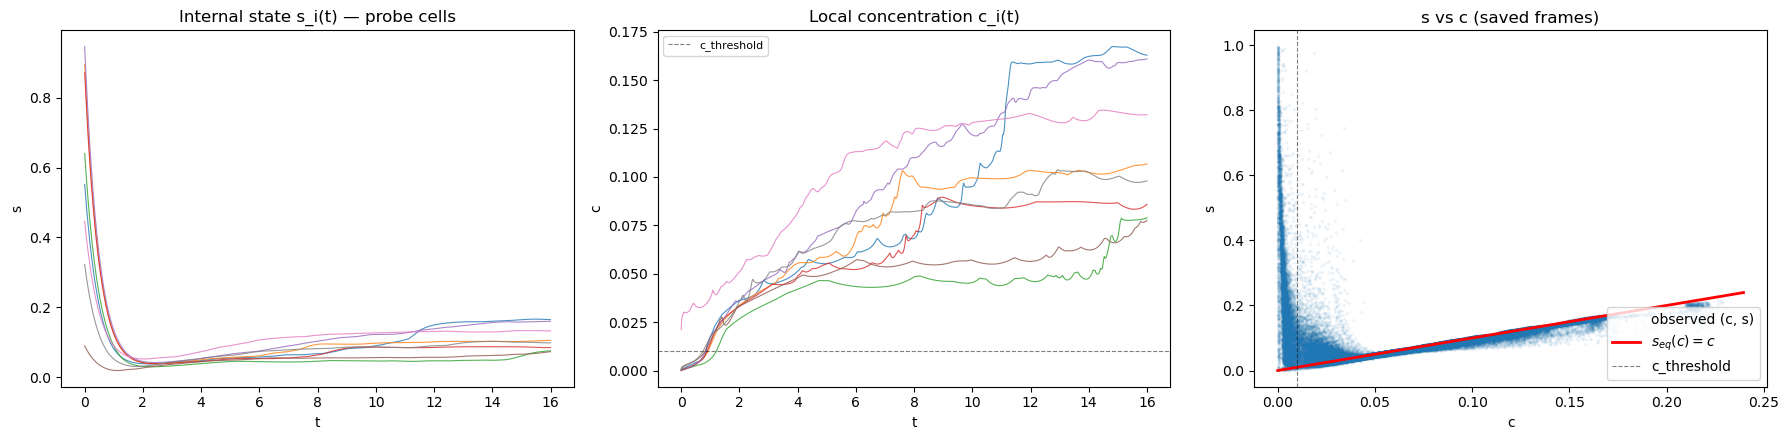

In [9]:
coeff_s     = field_params['internal_coeff_s']
coeff_emit  = field_params['internal_coeff_emit']
c_threshold = field_params['internal_c_threshold']

t_steps = np.arange(probe_s.shape[0]) * delta_t

fig, axes = plt.subplots(1, 3, figsize=(18, 4.5))

for j in range(n_probes):
    axes[0].plot(t_steps, probe_s[:, j], lw=0.8, alpha=0.8)
    axes[1].plot(t_steps, probe_c[:, j], lw=0.8, alpha=0.8)
axes[0].set_xlabel('t'); axes[0].set_ylabel('s'); axes[0].set_title('Internal state s_i(t) — probe cells')
axes[1].set_xlabel('t'); axes[1].set_ylabel('c'); axes[1].set_title('Local concentration c_i(t)')
axes[1].axhline(c_threshold, color='k', ls='--', lw=0.8, alpha=0.5, label='c_threshold')
axes[1].legend(loc='upper left', fontsize=8)

# (c, s) scatter vs equilibrium s = c
c_flat = field_history[..., 0].reshape(-1)
s_flat = field_history[..., 1].reshape(-1)
axes[2].scatter(c_flat, s_flat, s=2, alpha=0.05, color='C0', label='observed (c, s)')
c_max_plot = max(c_flat.max(), 0.01)
c_line = np.linspace(0, c_max_plot, 200)
axes[2].plot(c_line, c_line, 'r-', lw=2, label=r'$s_{eq}(c) = c$')
axes[2].axvline(c_threshold, color='k', ls='--', lw=0.8, alpha=0.5, label='c_threshold')
axes[2].set_xlabel('c'); axes[2].set_ylabel('s'); axes[2].set_title('s vs c (saved frames)')
axes[2].legend(loc='lower right')

plt.tight_layout()
plt.show()

## Internal-state distribution across all time frames

Two panels:
1. Aggregated histogram of every saved `s_i` value (all cells, all frames).
2. Time-resolved distribution: per-frame histogram of `s_i` rendered as a heatmap
   (x = time, y = `s` bins, colour = cell count).

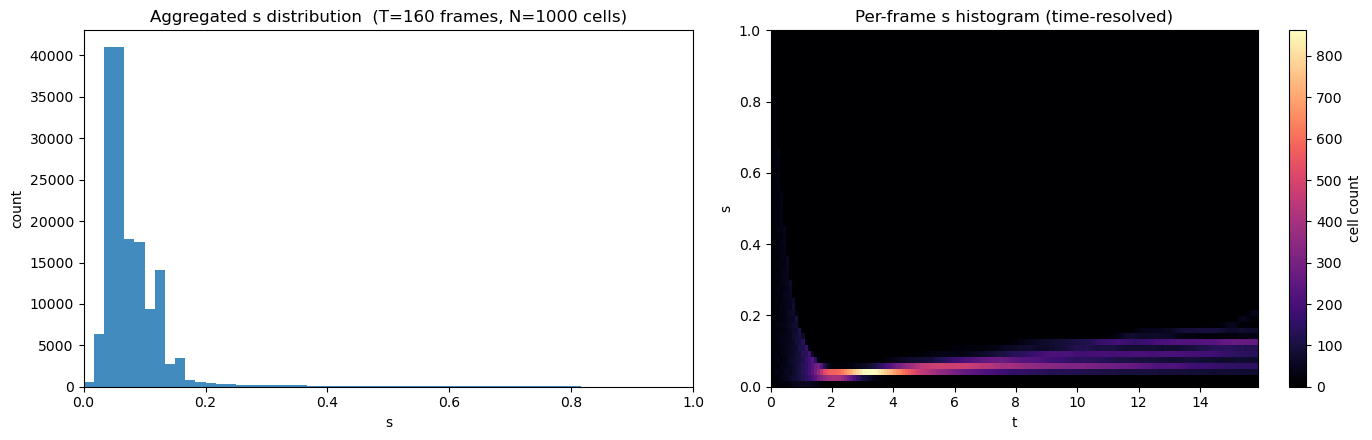

In [10]:
s_all = field_history[..., 1]            # (T, N)
T, N = s_all.shape

n_bins = 60
s_edges = np.linspace(0.0, 1.0, n_bins + 1)
s_centers = 0.5 * (s_edges[:-1] + s_edges[1:])

per_frame_hist = np.stack(
    [np.histogram(s_all[t], bins=s_edges)[0] for t in range(T)], axis=0
)  # (T, n_bins)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

axes[0].hist(s_all.ravel(), bins=s_edges, color='C0', alpha=0.85)
axes[0].set_xlabel('s'); axes[0].set_ylabel('count')
axes[0].set_title(f'Aggregated s distribution  (T={T} frames, N={N} cells)')
axes[0].set_xlim(0, 1)

im = axes[1].imshow(
    per_frame_hist.T,
    extent=[time_history[0], time_history[-1], s_edges[0], s_edges[-1]],
    origin='lower', aspect='auto', cmap='magma',
)
fig.colorbar(im, ax=axes[1], label='cell count')
axes[1].set_xlabel('t'); axes[1].set_ylabel('s')
axes[1].set_title('Per-frame s histogram (time-resolved)')

plt.tight_layout()
plt.show()

## Render 4-panel video

Panels: 3D scatter, particles colored by `s_i`, particles colored by `c_i`, mid-z field slice.

In [11]:
FPS = 30
n_snapshots = len(time_history)

vmax_field = max(grid_slice_history.max(), 1e-6)
vmax_c     = max(field_history[..., 0].max(), 1e-6)
vmax_s     = max(field_history[..., 1].max(), 1e-6)

particle_radius = 0.015
fig_w_per_panel = 5.0
pts_per_data = fig_w_per_panel * 72 * 0.65 / 1.0
PARTICLE_S = float(np.pi * (particle_radius * pts_per_data) ** 2)

fig = plt.figure(figsize=(20, 5))
ax1 = fig.add_subplot(141, projection='3d')
ax2 = fig.add_subplot(142)
ax3 = fig.add_subplot(143)
ax4 = fig.add_subplot(144)
_seed_img = ax4.imshow(np.zeros_like(grid_slice_history[0]), extent=[0, 1, 0, 1],
                       origin='lower', cmap='Oranges', vmin=0, vmax=vmax_field)
fig.colorbar(_seed_img, ax=ax4, fraction=0.046, pad=0.04, label='c(x,t)')

def update(frame_idx):
    p   = pos_history[frame_idx]
    fld = field_history[frame_idx]
    c_i = fld[:, 0]; s_i = fld[:, 1]
    img = grid_slice_history[frame_idx]
    t   = time_history[frame_idx]

    ax1.cla()
    ax1.scatter(p[:, 0], p[:, 1], p[:, 2], s=PARTICLE_S, c=s_i, cmap='viridis',
                vmin=0, vmax=vmax_s, alpha=0.7, edgecolors='none')
    ax1.set_xlim(0, 1); ax1.set_ylim(0, 1); ax1.set_zlim(0, 1)
    ax1.set_box_aspect([1, 1, 1]); ax1.set_xlabel('x'); ax1.set_ylabel('y'); ax1.set_zlabel('z')
    ax1.set_title(f'3D — color = s_i   t={t:.2f}')

    ax2.cla()
    ax2.scatter(p[:, 0], p[:, 1], s=PARTICLE_S, c=s_i, cmap='viridis',
                vmin=0, vmax=vmax_s, alpha=0.8, edgecolors='none')
    ax2.set_xlim(0, 1); ax2.set_ylim(0, 1); ax2.set_aspect('equal')
    ax2.set_xlabel('x'); ax2.set_ylabel('y'); ax2.set_title('Top-down — color = s_i')

    ax3.cla()
    ax3.scatter(p[:, 0], p[:, 1], s=PARTICLE_S, c=c_i, cmap='YlOrRd',
                vmin=0, vmax=vmax_c, alpha=0.8, edgecolors='none')
    ax3.set_xlim(0, 1); ax3.set_ylim(0, 1); ax3.set_aspect('equal')
    ax3.set_xlabel('x'); ax3.set_ylabel('y'); ax3.set_title('Top-down — color = c_i')

    ax4.cla()
    ax4.imshow(img, extent=[0, 1, 0, 1], origin='lower', cmap='Oranges',
               vmin=0, vmax=vmax_field, alpha=0.9)
    ax4.scatter(p[:, 0], p[:, 1], s=PARTICLE_S * 0.4, c='#1f77b4',
                alpha=0.5, edgecolors='none')
    ax4.set_xlim(0, 1); ax4.set_ylim(0, 1); ax4.set_aspect('equal')
    ax4.set_xlabel('x'); ax4.set_ylabel('y'); ax4.set_title('Field (z=0.5) + particles')

    fig.suptitle(f'Internal-state generator   t={t:.2f}', fontsize=14)

print(f'Rendering {n_snapshots} frames at fps={FPS}...')
ani = animation.FuncAnimation(fig, update, frames=n_snapshots, interval=1000/FPS)
video_path = str(OUT_DIR / 'internal_state_gt.mp4')
ani.save(video_path, writer='ffmpeg', fps=FPS, dpi=100)
plt.close(fig)
print(f'-> {video_path}')

Rendering 160 frames at fps=30...
-> ../presentation/videos/internal_state_gt.mp4
